In [ ]:
#Importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

In [ ]:
patients_data = pd.read_csv("plan b data.csv", index_col=0)

In [ ]:
patients_data

,Diagnosis,VisualG,SUVmax,TBR,ConclusionPET,ABusepostoper,minimum_intensity,maximum_intensity,range,mean_intensity,...,gray_level_nonuniformity_A,size_zone_nonuniformity,zone_percentage,low_gray_level_zone_emphasis,high_gray_level_zone_emphasis,small_zone_low_gray_level_emphasis,small_zone_high_gray_level_emphasis,large_zone_low_gray_level_emphasis,large_zone_high_gray_level_emphasis,filter_$
Patients,,,,,,,,,,,,,,,,,,,,,
1,1,4,6.7,3.72,2,1,0.62,6.68,6.07,2.34,...,16.08,25.22,0.00,0.23,9.939963e+07,0.01,9.860538e+07,11.75,1.229531e+08,0
2,1,3,9.8,4.90,1,1,0.34,9.66,9.32,2.61,...,68.59,37.58,0.00,0.40,2.941573e+08,0.01,2.939368e+08,28.57,3.034294e+08,0
3,1,3,5.3,4.42,1,1,0.08,5.28,5.20,1.72,...,20.20,18.46,0.00,0.36,1.688961e+09,0.03,1.688835e+09,10.02,1.691300e+09,0
4,1,4,11.2,10.18,1,1,0.47,8.50,8.03,2.21,...,11.73,8.39,0.00,0.29,1.263940e+07,0.01,1.259057e+07,31.82,1.366822e+07,0
5,1,4,9.1,6.59,1,1,0.60,8.30,7.70,2.71,...,10.32,5.95,0.00,0.36,1.278671e+07,0.01,1.277919e+07,31.71,1.305688e+07,0
6,1,4,6.3,3.94,1,1,0.70,6.28,5.58,2.70,...,6.46,7.92,0.00,0.33,3.082371e+06,0.01,3.017416e+06,23.82,5.376431e+06,0
7,1,4,4.9,4.45,1,1,0.48,4.87,4.39,1.70,...,7.19,11.14,0.00,0.25,7.772283e+07,0.02,7.742148e+07,9.02,8.304376e+07,0
8,1,4,6.1,4.69,1,1,0.82,6.11,5.29,2.36,...,2.59,3.77,0.00,0.21,1.662223e+06,0.01,1.625534e+06,12.66,2.738375e+06,0
9,1,3,10.3,2.86,1,1,0.44,6.76,6.32,3.01,...,43.75,30.46,0.02,0.35,1.049818e+04,0.03,3.211200e+02,15.54,4.590263e+05,0


In [ ]:
#In practice, feature selection should be done after data pre-processing, so ideally, all the categorical variables are encoded into numbers
numerics = ['int16','int32','int64','float16','float32','float64']
numerical_vars = list(patients_data.select_dtypes(include=numerics).columns)
patients_data = patients_data[numerical_vars]
patients_data

,Diagnosis,VisualG,SUVmax,TBR,ConclusionPET,ABusepostoper,minimum_intensity,maximum_intensity,range,mean_intensity,...,gray_level_nonuniformity_A,size_zone_nonuniformity,zone_percentage,low_gray_level_zone_emphasis,high_gray_level_zone_emphasis,small_zone_low_gray_level_emphasis,small_zone_high_gray_level_emphasis,large_zone_low_gray_level_emphasis,large_zone_high_gray_level_emphasis,filter_$
Patients,,,,,,,,,,,,,,,,,,,,,
1,1,4,6.7,3.72,2,1,0.62,6.68,6.07,2.34,...,16.08,25.22,0.00,0.23,9.939963e+07,0.01,9.860538e+07,11.75,1.229531e+08,0
2,1,3,9.8,4.90,1,1,0.34,9.66,9.32,2.61,...,68.59,37.58,0.00,0.40,2.941573e+08,0.01,2.939368e+08,28.57,3.034294e+08,0
3,1,3,5.3,4.42,1,1,0.08,5.28,5.20,1.72,...,20.20,18.46,0.00,0.36,1.688961e+09,0.03,1.688835e+09,10.02,1.691300e+09,0
4,1,4,11.2,10.18,1,1,0.47,8.50,8.03,2.21,...,11.73,8.39,0.00,0.29,1.263940e+07,0.01,1.259057e+07,31.82,1.366822e+07,0
5,1,4,9.1,6.59,1,1,0.60,8.30,7.70,2.71,...,10.32,5.95,0.00,0.36,1.278671e+07,0.01,1.277919e+07,31.71,1.305688e+07,0
6,1,4,6.3,3.94,1,1,0.70,6.28,5.58,2.70,...,6.46,7.92,0.00,0.33,3.082371e+06,0.01,3.017416e+06,23.82,5.376431e+06,0
7,1,4,4.9,4.45,1,1,0.48,4.87,4.39,1.70,...,7.19,11.14,0.00,0.25,7.772283e+07,0.02,7.742148e+07,9.02,8.304376e+07,0
8,1,4,6.1,4.69,1,1,0.82,6.11,5.29,2.36,...,2.59,3.77,0.00,0.21,1.662223e+06,0.01,1.625534e+06,12.66,2.738375e+06,0
9,1,3,10.3,2.86,1,1,0.44,6.76,6.32,3.01,...,43.75,30.46,0.02,0.35,1.049818e+04,0.03,3.211200e+02,15.54,4.590263e+05,0


In [ ]:
patients_data.isnull().sum()

Diagnosis                              0
VisualG                                0
SUVmax                                 0
TBR                                    0
ConclusionPET                          0
                                      ..
small_zone_low_gray_level_emphasis     0
small_zone_high_gray_level_emphasis    0
large_zone_low_gray_level_emphasis     0
large_zone_high_gray_level_emphasis    0
filter_$                               0
Length: 107, dtype: int64

In [ ]:
X = patients_data.drop(['Diagnosis'], axis=1)
y = patients_data['Diagnosis']

In [ ]:
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
# summarize
print('Train', X_train.shape, y_train.shape)
print('Test', X_test.shape, y_test.shape)

Train (20, 106) (20,)
Test (10, 106) (10,)


In [ ]:
#Scaling the data
scaler = StandardScaler()
scaler.fit(X_train.fillna(0))

StandardScaler()

In [ ]:
# example of mutual information feature selection for numerical input data
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import mutual_info_classif
from matplotlib import pyplot
# configure to select all features
fs = SelectKBest(score_func=f_classif, k='all')
# learn relationship from training data
fs.fit(X_train, y_train)
# transform train input data
X_train_fs = fs.transform(X_train)
# transform test input data
X_test_fs = fs.transform(X_test)

/Users/Hanaly/anaconda3/lib/python3.6/site-packages/sklearn/feature_selection/_univariate_selection.py:115: UserWarning: Features [68 69] are constant.
  UserWarning)
/Users/Hanaly/anaconda3/lib/python3.6/site-packages/sklearn/feature_selection/_univariate_selection.py:116: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Feature 0: 6.495338
Feature 1: 4.172848
Feature 2: 0.541719
Feature 3: 19.459459
Feature 4: 14.175000
Feature 5: 2.355035
Feature 6: 2.807246
Feature 7: 2.209868
Feature 8: 7.835628
Feature 9: 4.349180
Feature 10: 3.103117
Feature 11: 4.794998
Feature 12: 8.643969
Feature 13: 6.421778
Feature 14: 2.107322
Feature 15: 4.991109
Feature 16: 5.440823
Feature 17: 0.004232
Feature 18: 0.925964
Feature 19: 3.099801
Feature 20: 0.519113
Feature 21: 0.878509
Feature 22: 7.971341
Feature 23: 0.235045
Feature 24: 3.579728
Feature 25: 3.615706
Feature 26: 2.221958
Feature 27: 2.312123
Feature 28: 2.032558
Feature 29: 0.267546
Feature 30: 2.032558
Feature 31: 0.267546
Feature 32: 3.466165
Feature 33: 3.673563
Feature 34: 2.640727
Feature 35: 2.725606
Feature 36: 3.660450
Feature 37: 3.850720
Feature 38: 2.128377
Feature 39: 2.000343
Feature 40: 0.704726
Feature 41: 1.028896
Feature 42: 1.582976
Feature 43: 1.503331
Feature 44: 2.204609
Feature 45: 3.958322
Feature 46: 2.057383
Feature 47: 4.016086


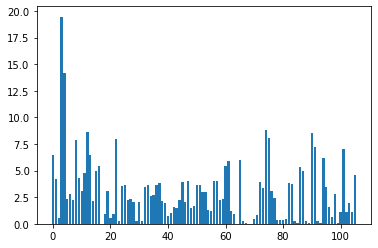

In [ ]:
# what are scores for the features
for i in range(len(fs.scores_)):
    print('Feature %d: %f' % (i, fs.scores_[i]))
# plot the scores
pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()

In [ ]:
#the features with the highest scores are the ones to be selected, they can also be seen from the above graph